In [1]:
#importing

import pandas as pd
import numpy as np
import seaborn as sns
import statistics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from IPython.display import Image, display
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

df = pd.read_csv("QCAnomalyTrainingData.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 99999 non-null  object 
 1   STD_LOT_CODE                    99999 non-null  object 
 2   STD_CODE                        99999 non-null  object 
 3   JOB_CODE                        99999 non-null  object 
 4   NUMERIC_FINAL_VALUE             99999 non-null  float64
 5   ANALYSED_DATE                   99999 non-null  object 
 6   SCHEME_CODE                     99999 non-null  object 
 7   ANALYTE_CODE                    98871 non-null  object 
 8   STANDARD_STATUS                 54675 non-null  object 
 9   PRECISION_STATUS                45315 non-null  object 
 10  INTERNAL_MIN_VALUE              54447 non-null  float64
 11  INTERNAL_MAX_VALUE              54447 non-null  float64
 12  INTERNAL_MIN_INCLUSIVE          

C:\Users\jknig\AppData\Local\Temp\ipykernel_49952\3781040326.py:15: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("QCAnomalyTrainingData.csv")


In [2]:
num_col = df.select_dtypes(include=['number'])
correlation_matrix = num_col.corr()
correlation_matrix

,NUMERIC_FINAL_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE
NUMERIC_FINAL_VALUE,1.000000,0.971917,0.971910,0.971829,0.971832,-0.014033,-0.007624,-0.012435,-0.007594,0.854144,0.998033
INTERNAL_MIN_VALUE,0.971917,1.000000,0.999999,1.000000,1.000000,-0.017727,0.000561,-0.015824,0.000603,0.881030,NaN
INTERNAL_MAX_VALUE,0.971910,0.999999,1.000000,1.000000,1.000000,-0.017820,0.001642,-0.015989,0.001685,0.881020,NaN
INTERNAL_MAX_WARNING_VALUE,0.971829,1.000000,1.000000,1.000000,1.000000,-0.021773,0.000713,-0.019438,0.000764,0.880619,NaN
INTERNAL_MIN_WARNING_VALUE,0.971832,1.000000,1.000000,1.000000,1.000000,-0.021725,0.000254,-0.019383,0.000304,0.880622,NaN
LIM_REP_VALUE,-0.014033,-0.017727,-0.017820,-0.021773,-0.021725,1.000000,-0.105017,0.863807,-0.104899,-0.019098,-0.010001
STAT_DL_VALUE,-0.007624,0.000561,0.001642,0.000713,0.000254,-0.105017,1.000000,-0.105292,0.999863,0.002393,-0.015039
LIM_REP_DUP_VALUE,-0.012435,-0.015824,-0.015989,-0.019438,-0.019383,0.863807,-0.105292,1.000000,-0.105188,-0.017104,-0.008772
STAT_DL_DUP_VALUE,-0.007594,0.000603,0.001685,0.000764,0.000304,-0.104899,0.999863,-0.105188,1.000000,0.002438,-0.015019
INTERNAL_TARGET_VALUE,0.854144,0.881030,0.881020,0.880619,0.880622,-0.019098,0.002393,-0.017104,0.002438,1.000000,NaN


In [3]:
df = df[df['ANALYTICAL_TYPE'] == 'Blank']

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17997 entries, 6 to 99998
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17997 non-null  object 
 1   STD_LOT_CODE                    17997 non-null  object 
 2   STD_CODE                        17997 non-null  object 
 3   JOB_CODE                        17997 non-null  object 
 4   NUMERIC_FINAL_VALUE             17997 non-null  float64
 5   ANALYSED_DATE                   17997 non-null  object 
 6   SCHEME_CODE                     17997 non-null  object 
 7   ANALYTE_CODE                    17831 non-null  object 
 8   STANDARD_STATUS                 17993 non-null  object 
 9   PRECISION_STATUS                0 non-null      object 
 10  INTERNAL_MIN_VALUE              17997 non-null  float64
 11  INTERNAL_MAX_VALUE              17997 non-null  float64
 12  INTERNAL_MIN_INCLUSIVE          17997

In [4]:
#Dropping columns and filtering
filtered_df = df.drop(['UNIT_CODE', 'SPECIFICATION_CODE', 'PARENT_NUMERIC_FINAL_VALUE', 'INSTRUMENT_ID', 'INTERNAL_MAX_WARNING_VALUE', 'INTERNAL_MIN_WARNING_VALUE', 'PRECISION_STATUS', 'STD_LOT_CODE', 'STD_CODE'], axis=1, inplace=False)

filtered_df = filtered_df.dropna()

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17827 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17827 non-null  object 
 1   JOB_CODE                        17827 non-null  object 
 2   NUMERIC_FINAL_VALUE             17827 non-null  float64
 3   ANALYSED_DATE                   17827 non-null  object 
 4   SCHEME_CODE                     17827 non-null  object 
 5   ANALYTE_CODE                    17827 non-null  object 
 6   STANDARD_STATUS                 17827 non-null  object 
 7   INTERNAL_MIN_VALUE              17827 non-null  float64
 8   INTERNAL_MAX_VALUE              17827 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17827 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17827 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17827 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17827

In [5]:
filtered_df.value_counts()

ANALYTICAL_TYPE  JOB_CODE          NUMERIC_FINAL_VALUE  ANALYSED_DATE  SCHEME_CODE  ANALYTE_CODE  STANDARD_STATUS  INTERNAL_MIN_VALUE  INTERNAL_MAX_VALUE  INTERNAL_MIN_INCLUSIVE  INTERNAL_MAX_INCLUSIVE  INTERNAL_MIN_WARNING_INCLUSIVE  INTERNAL_MAX_WARNING_INCLUSIVE  LIM_REP_VALUE  STAT_DL_VALUE  LIM_REP_DUP_VALUE  STAT_DL_DUP_VALUE  INTERNAL_TARGET_VALUE
Blank            TSV_LB0003795557  0.009000             51:13.0        GE_IMS40Q12  W             Pass             -0.250              0.250               Y                       Y                       Y                               Y                               15             0.250          22.5               0.250              0.0                      2
                 TSV_LB0002670477  0.008800             12:47.0        GE_IMS40Q12  TE            Pass             -0.500              0.500               Y                       Y                       Y                               Y                               10            

In [6]:
# importing
import matplotlib.pyplot as plt
import seaborn as sns

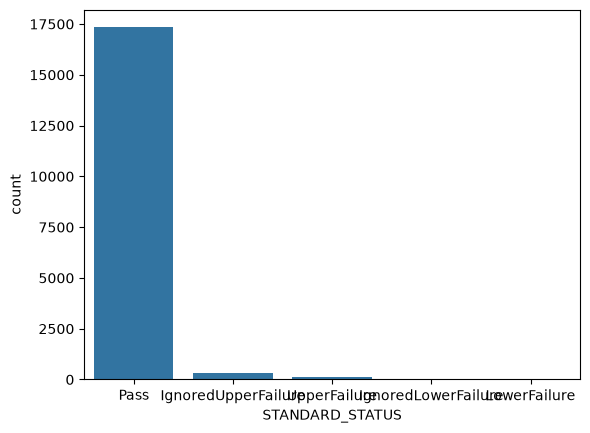

In [7]:
dg = sns.countplot(data=filtered_df, x='STANDARD_STATUS')
plt.show()

<Axes: xlabel='ANALYSED_DATE'>

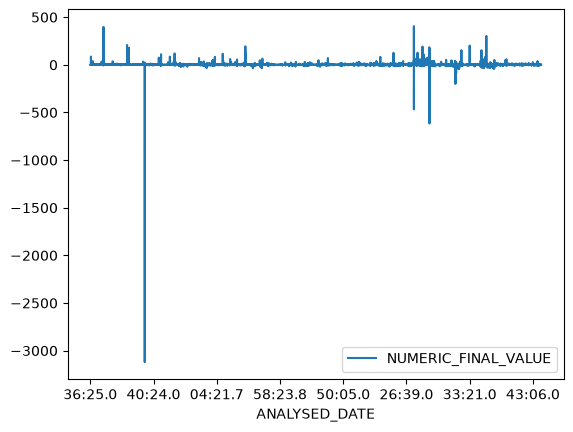

In [8]:
filtered_df.plot(x='ANALYSED_DATE', y='NUMERIC_FINAL_VALUE')

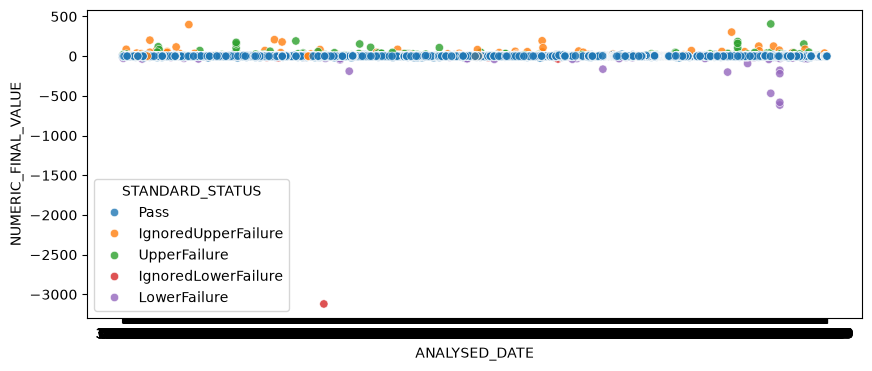

In [10]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=filtered_df, 
    x='ANALYSED_DATE', 
    y='NUMERIC_FINAL_VALUE', 
    hue='STANDARD_STATUS',
    alpha=0.8
)
plt.show()

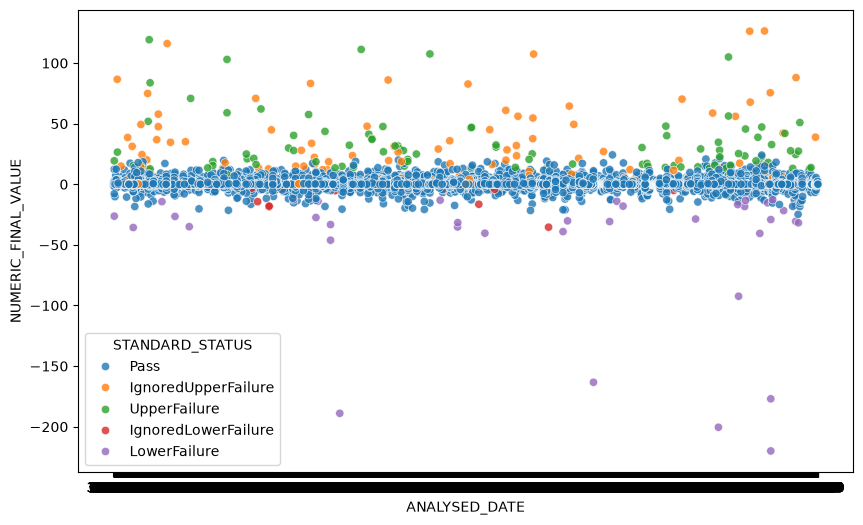

In [11]:
df_withoutoutlier = filtered_df[(filtered_df['NUMERIC_FINAL_VALUE'] >= -300) & (filtered_df['NUMERIC_FINAL_VALUE'] <= 150)]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_withoutoutlier, 
    x='ANALYSED_DATE', 
    y='NUMERIC_FINAL_VALUE', 
    hue='STANDARD_STATUS',
    alpha=0.8
)
plt.show()

## CREATING A TEST/TRAIN PARTITION

In [12]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17827 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17827 non-null  object 
 1   JOB_CODE                        17827 non-null  object 
 2   NUMERIC_FINAL_VALUE             17827 non-null  float64
 3   ANALYSED_DATE                   17827 non-null  object 
 4   SCHEME_CODE                     17827 non-null  object 
 5   ANALYTE_CODE                    17827 non-null  object 
 6   STANDARD_STATUS                 17827 non-null  object 
 7   INTERNAL_MIN_VALUE              17827 non-null  float64
 8   INTERNAL_MAX_VALUE              17827 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17827 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17827 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17827 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17827

In [13]:
filtered_df['STANDARD_STATUS'] = filtered_df['STANDARD_STATUS'].fillna(statistics.mode(filtered_df['STANDARD_STATUS']))
filtered_df.info()
"""
print("new: \n -----------")

filtered_df.info()
"""

<class 'pandas.core.frame.DataFrame'>
Index: 17827 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17827 non-null  object 
 1   JOB_CODE                        17827 non-null  object 
 2   NUMERIC_FINAL_VALUE             17827 non-null  float64
 3   ANALYSED_DATE                   17827 non-null  object 
 4   SCHEME_CODE                     17827 non-null  object 
 5   ANALYTE_CODE                    17827 non-null  object 
 6   STANDARD_STATUS                 17827 non-null  object 
 7   INTERNAL_MIN_VALUE              17827 non-null  float64
 8   INTERNAL_MAX_VALUE              17827 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17827 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17827 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17827 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17827

'\nprint("new: \n -----------")\n\nfiltered_df.info()\n'

In [16]:
filtered_df.info()

Y = filtered_df["STANDARD_STATUS"]
X = filtered_df.drop(["STANDARD_STATUS"], axis=1)
X = pd.get_dummies(X)

feature_names = X.columns

X.reindex(columns=feature_names, fill_value=0)



filtered_df.info()


# splitting 

random_state = 10
test_set_size = 0.3 # doing a 30/70 split

X_train, X_test, y_train, y_test = train_test_split(X.values, Y, test_size=test_set_size, stratify=Y, random_state=random_state)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

<class 'pandas.core.frame.DataFrame'>
Index: 17827 entries, 6 to 99998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17827 non-null  object 
 1   JOB_CODE                        17827 non-null  object 
 2   NUMERIC_FINAL_VALUE             17827 non-null  float64
 3   ANALYSED_DATE                   17827 non-null  object 
 4   SCHEME_CODE                     17827 non-null  object 
 5   ANALYTE_CODE                    17827 non-null  object 
 6   STANDARD_STATUS                 17827 non-null  object 
 7   INTERNAL_MIN_VALUE              17827 non-null  float64
 8   INTERNAL_MAX_VALUE              17827 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17827 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17827 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17827 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17827

In [17]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("Bf Scaling\n-=-=-=-=-=-=-")


for i in range(5):
    col = X_train[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i, min(col), max(col), np.mean(col), np.std(col)))

X_train = scaler.fit_transform (X_train, y_train)

print("Af Scaling\n-=-=-=-=-=-=-")

for i in range(5):
    col = X_train[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i, min(col), max(col), np.mean(col), np.std(col)))

X_test = scaler.transform(X_test)

Bf Scaling
-=-=-=-=-=-=-
Variable #0: min -3120.62395, max 405.93, mean 0.42 and std dev 29.79
Variable #1: min -50.0, max -0.0025, mean -7.17 and std dev 9.83
Variable #2: min 0.0025, max 50.0, mean 7.17 and std dev 9.83
Variable #3: min 10, max 15, mean 10.24 and std dev 1.07
Variable #4: min 0.025, max 50.0, mean 4.08 and std dev 7.11
Af Scaling
-=-=-=-=-=-=-
Variable #0: min -104.77800407417412, max 13.613610580174452, mean 0.00 and std dev 1.00
Variable #1: min -4.354891166662891, max 0.729094052832352, mean -0.00 and std dev 1.00
Variable #2: min -0.729094052832352, max 4.354891166662891, mean 0.00 and std dev 1.00
Variable #3: min -0.22455538283369633, max 4.453244395127689, mean 0.00 and std dev 1.00
Variable #4: min -0.5703618302316047, max 6.454977915546483, mean -0.00 and std dev 1.00


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=random_state)

model.fit(X_train, y_train)

F:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=10)

In [19]:
from sklearn.metrics import classification_report

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Train accuracy: 0.9973553454079179
Test accuracy: 0.9652271452607964
                     precision    recall  f1-score   support

IgnoredLowerFailure       0.09      0.11      0.10         9
IgnoredUpperFailure       0.24      0.16      0.20        91
       LowerFailure       0.40      0.29      0.33        14
               Pass       0.98      0.99      0.98      5199
       UpperFailure       0.55      0.33      0.41        36

           accuracy                           0.97      5349
          macro avg       0.45      0.38      0.41      5349
       weighted avg       0.96      0.97      0.96      5349



In [20]:

filtered_df['Prediction'] = model.predict(X)

filtered_df.info()



F:\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
Index: 17827 entries, 6 to 99998
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ANALYTICAL_TYPE                 17827 non-null  object 
 1   JOB_CODE                        17827 non-null  object 
 2   NUMERIC_FINAL_VALUE             17827 non-null  float64
 3   ANALYSED_DATE                   17827 non-null  object 
 4   SCHEME_CODE                     17827 non-null  object 
 5   ANALYTE_CODE                    17827 non-null  object 
 6   STANDARD_STATUS                 17827 non-null  object 
 7   INTERNAL_MIN_VALUE              17827 non-null  float64
 8   INTERNAL_MAX_VALUE              17827 non-null  float64
 9   INTERNAL_MIN_INCLUSIVE          17827 non-null  object 
 10  INTERNAL_MAX_INCLUSIVE          17827 non-null  object 
 11  INTERNAL_MIN_WARNING_INCLUSIVE  17827 non-null  object 
 12  INTERNAL_MAX_WARNING_INCLUSIVE  17827

In [30]:

"""
we needed these before so these were snagged from the other notebook.
"""


GROUP_COLUMNS = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
]

filtered_df["TARGET_DEVIATION"] = (
    filtered_df["NUMERIC_FINAL_VALUE"]
    - filtered_df["INTERNAL_TARGET_VALUE"]
)

filtered_df["GROUP_MEDIAN"] = (
    filtered_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"].transform("median")
)

filtered_df["ABS_MEDIAN_DEVIATION"] = (
    filtered_df["NUMERIC_FINAL_VALUE"]
    - filtered_df["GROUP_MEDIAN"]
).abs()

filtered_df["GROUP_MAD"] = (
    filtered_df.groupby(GROUP_COLUMNS)["ABS_MEDIAN_DEVIATION"].transform("median")
)

# drift report

filtered_df["ROLL_MEDIAN"] = (
    filtered_df.groupby(GROUP_COLUMNS, dropna=True)["NUMERIC_FINAL_VALUE"]
    .transform(lambda x: x.rolling(window=10, min_periods=3).median())
)

filtered_df["ROLLING_CHANGE"] = (
    filtered_df["ROLL_MEDIAN"]
    - filtered_df["GROUP_MEDIAN"]
)


display(filtered_df)


,ANALYTICAL_TYPE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,...,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,Prediction,TARGET_DEVIATION,GROUP_MEDIAN,ABS_MEDIAN_DEVIATION,GROUP_MAD,ROLL_MEDIAN,ROLLING_CHANGE
6,Blank,TSV_LB0016663011,-0.139828,36:25.0,GE_IMS40Q12,NI,Pass,-5.000,5.000,Y,...,15.0,5.000,0.0,Pass,-0.139828,0.897959,1.037787,0.468500,NaN,NaN
16,Blank,TSV_LB0016663011,0.241648,35:30.0,GE_IMS40Q12,CU,Pass,-5.000,5.000,Y,...,15.0,5.000,0.0,Pass,0.241648,0.699600,0.457952,0.479600,NaN,NaN
17,Blank,TSV_LB0016663011,0.335467,35:19.0,GE_IMS40Q12,ZN,Pass,-12.500,12.500,Y,...,15.0,12.500,0.0,LowerFailure,0.335467,1.622162,1.286696,1.182162,NaN,NaN
18,Blank,TSV_LB0016663011,-0.034207,35:09.0,GE_IMS40Q12,PB,Pass,-2.500,2.500,Y,...,15.0,1.250,0.0,Pass,-0.034207,0.529106,0.563313,0.487097,NaN,NaN
19,Blank,TSV_LB0016663011,0.011002,34:53.0,GE_IMS40Q12,AG,Pass,-0.125,0.125,Y,...,15.0,0.050,0.0,Pass,0.011002,0.020000,0.008998,0.020000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,Blank,TSV_LB0002628992,-0.044000,09:52.0,GE_IMS40Q12,AS,Pass,-2.500,2.500,Y,...,15.0,2.500,0.0,Pass,-0.044000,0.179968,0.223968,0.244049,0.14454,-0.035428
99983,Blank,TSV_LB0002628992,0.066000,09:52.0,GE_IMS40Q12,SE,Pass,-5.000,5.000,Y,...,15.0,5.000,0.0,Pass,0.066000,0.088509,0.022509,0.193500,0.04200,-0.046509
99984,Blank,TSV_LB0002628992,0.004000,09:52.0,GE_IMS40Q12,BI,Pass,-0.250,0.250,Y,...,15.0,0.100,0.0,Pass,0.004000,0.013003,0.009003,0.012003,0.01250,-0.000503
99985,Blank,TSV_LB0002628992,0.001000,09:52.0,GE_IMS40Q12,TE,Pass,-0.500,0.500,Y,...,15.0,0.125,0.0,Pass,0.001000,0.008100,0.007100,0.012100,0.00880,0.000700


In [31]:
filtered_df["ROB_Z_SCORE"] = np.where(
    filtered_df["GROUP_MAD"] > 0,
    0.6745 * (filtered_df["NUMERIC_FINAL_VALUE"] - filtered_df["GROUP_MEDIAN"])
    / filtered_df["GROUP_MAD"],
    np.nan,
)

display(filtered_df)

,ANALYTICAL_TYPE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,...,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,Prediction,TARGET_DEVIATION,GROUP_MEDIAN,ABS_MEDIAN_DEVIATION,GROUP_MAD,ROLL_MEDIAN,ROLLING_CHANGE,ROB_Z_SCORE
6,Blank,TSV_LB0016663011,-0.139828,36:25.0,GE_IMS40Q12,NI,Pass,-5.000,5.000,Y,...,5.000,0.0,Pass,-0.139828,0.897959,1.037787,0.468500,NaN,NaN,-1.494103
16,Blank,TSV_LB0016663011,0.241648,35:30.0,GE_IMS40Q12,CU,Pass,-5.000,5.000,Y,...,5.000,0.0,Pass,0.241648,0.699600,0.457952,0.479600,NaN,NaN,-0.644054
17,Blank,TSV_LB0016663011,0.335467,35:19.0,GE_IMS40Q12,ZN,Pass,-12.500,12.500,Y,...,12.500,0.0,LowerFailure,0.335467,1.622162,1.286696,1.182162,NaN,NaN,-0.734143
18,Blank,TSV_LB0016663011,-0.034207,35:09.0,GE_IMS40Q12,PB,Pass,-2.500,2.500,Y,...,1.250,0.0,Pass,-0.034207,0.529106,0.563313,0.487097,NaN,NaN,-0.780038
19,Blank,TSV_LB0016663011,0.011002,34:53.0,GE_IMS40Q12,AG,Pass,-0.125,0.125,Y,...,0.050,0.0,Pass,0.011002,0.020000,0.008998,0.020000,NaN,NaN,-0.303451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,Blank,TSV_LB0002628992,-0.044000,09:52.0,GE_IMS40Q12,AS,Pass,-2.500,2.500,Y,...,2.500,0.0,Pass,-0.044000,0.179968,0.223968,0.244049,0.14454,-0.035428,-0.619001
99983,Blank,TSV_LB0002628992,0.066000,09:52.0,GE_IMS40Q12,SE,Pass,-5.000,5.000,Y,...,5.000,0.0,Pass,0.066000,0.088509,0.022509,0.193500,0.04200,-0.046509,-0.078461
99984,Blank,TSV_LB0002628992,0.004000,09:52.0,GE_IMS40Q12,BI,Pass,-0.250,0.250,Y,...,0.100,0.0,Pass,0.004000,0.013003,0.009003,0.012003,0.01250,-0.000503,-0.505912
99985,Blank,TSV_LB0002628992,0.001000,09:52.0,GE_IMS40Q12,TE,Pass,-0.500,0.500,Y,...,0.125,0.0,Pass,0.001000,0.008100,0.007100,0.012100,0.00880,0.000700,-0.395781


In [38]:
filtered_df["P_ANOM"] = (
    filtered_df["ROB_Z_SCORE"] > 3
)

display(filtered_df)

print(
    "Point-anomaly candidates:",
    filtered_df["P_ANOM"].sum()
)


,ANALYTICAL_TYPE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,...,INTERNAL_TARGET_VALUE,Prediction,TARGET_DEVIATION,GROUP_MEDIAN,ABS_MEDIAN_DEVIATION,GROUP_MAD,ROLL_MEDIAN,ROLLING_CHANGE,ROB_Z_SCORE,P_ANOM
6,Blank,TSV_LB0016663011,-0.139828,36:25.0,GE_IMS40Q12,NI,Pass,-5.000,5.000,Y,...,0.0,Pass,-0.139828,0.897959,1.037787,0.468500,NaN,NaN,-1.494103,False
16,Blank,TSV_LB0016663011,0.241648,35:30.0,GE_IMS40Q12,CU,Pass,-5.000,5.000,Y,...,0.0,Pass,0.241648,0.699600,0.457952,0.479600,NaN,NaN,-0.644054,False
17,Blank,TSV_LB0016663011,0.335467,35:19.0,GE_IMS40Q12,ZN,Pass,-12.500,12.500,Y,...,0.0,LowerFailure,0.335467,1.622162,1.286696,1.182162,NaN,NaN,-0.734143,False
18,Blank,TSV_LB0016663011,-0.034207,35:09.0,GE_IMS40Q12,PB,Pass,-2.500,2.500,Y,...,0.0,Pass,-0.034207,0.529106,0.563313,0.487097,NaN,NaN,-0.780038,False
19,Blank,TSV_LB0016663011,0.011002,34:53.0,GE_IMS40Q12,AG,Pass,-0.125,0.125,Y,...,0.0,Pass,0.011002,0.020000,0.008998,0.020000,NaN,NaN,-0.303451,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,Blank,TSV_LB0002628992,-0.044000,09:52.0,GE_IMS40Q12,AS,Pass,-2.500,2.500,Y,...,0.0,Pass,-0.044000,0.179968,0.223968,0.244049,0.14454,-0.035428,-0.619001,False
99983,Blank,TSV_LB0002628992,0.066000,09:52.0,GE_IMS40Q12,SE,Pass,-5.000,5.000,Y,...,0.0,Pass,0.066000,0.088509,0.022509,0.193500,0.04200,-0.046509,-0.078461,False
99984,Blank,TSV_LB0002628992,0.004000,09:52.0,GE_IMS40Q12,BI,Pass,-0.250,0.250,Y,...,0.0,Pass,0.004000,0.013003,0.009003,0.012003,0.01250,-0.000503,-0.505912,False
99985,Blank,TSV_LB0002628992,0.001000,09:52.0,GE_IMS40Q12,TE,Pass,-0.500,0.500,Y,...,0.0,Pass,0.001000,0.008100,0.007100,0.012100,0.00880,0.000700,-0.395781,False


Point-anomaly candidates: 1148
